
# Gravitational Clustering de Wright (1977)

## Referencia principal

- Wright, W. E. (1977). *Gravitational Clustering*. **Pattern Recognition**, 9, 151--166.



## 1. Marco teórico según Wright (1977)

Wright plantea el clustering como un proceso dinámico sobre un conjunto finito de partículas en un espacio euclidiano. Cada observación inicial es una partícula con posición $s_i$ y masa $m_i$. A medida que el sistema evoluciona, las partículas se atraen entre sí; cuando dos partículas quedan suficientemente cerca, se fusionan en una nueva partícula ubicada en su centroide ponderado. La secuencia de fusiones induce una jerarquía aglomerativa.

### 1.1 Modelo formal

En el procedimiento formal del paper deben fijarse dos parámetros de aproximación:

- $\delta$: distancia máxima recorrida por la partícula más rápida en un paso de simulación.
- $\epsilon$: umbral de colisión; Wright recomienda usualmente $\epsilon = 2\delta$.

En cada iteración se actualiza la posición mediante

$$
 s_i(t + dt) = s_i(t) + g(i,t,dt),
$$

siendo $g$ la función gravitacional elegida.

### 1.2 Modelo físico modificado y versión Markoviana

Wright argumenta que la dinámica física completa no es la opción más conveniente para clustering porque incorpora velocidad acumulada. Por ello introduce una versión **Markoviana**, en la que el desplazamiento depende únicamente del estado actual del sistema.

La familia Markoviana generalizada del paper puede escribirse como

$$
 g(i,t,dt)
 = dt^2 
 \sum_{j \in N(t),\, j \ne i}
 \frac{m_i^{p}(t)m_j^{q}(t)}{m_i(t)}
 \frac{s_j(t)-s_i(t)}{\lVert s_j(t)-s_i(t) \rVert^3}.
$$

### 1.3 Modelo usado en este cuaderno: *unit attraction Markovian model*

El artículo destaca especialmente el caso $p=0$ y $q=0$, al que denomina **unit attraction Markovian model**. En esta variante, la atracción entre dos partículas es unitaria y el efecto de la masa aparece únicamente como un término de arrastre inversamente proporcional a la masa de la partícula que se mueve:

$$
 g(i,t,dt)
 = dt^2 
 \sum_{j \in N(t),\, j \ne i}
 \frac{1}{m_i(t)}
 \frac{s_j(t)-s_i(t)}{\lVert s_j(t)-s_i(t) \rVert^3}.
$$

Esta es la ecuación implementada aquí por defecto.

### 1.4 Regla de fusión

Si dos partículas $i$ y $j$ quedan a distancia menor que $\epsilon$, se sustituyen por una partícula con masa total

$$
 m_{ij}(t) = m_i(t) + m_j(t),
$$

y localización en el centroide ponderado

$$
 s_{ij}(t) = \frac{m_i(t)s_i(t) + m_j(t)s_j(t)}{m_i(t)+m_j(t)}.
$$

### 1.5 Criterio de interpretación

La clave interpretativa del paper no es solo la partición final, sino el **tiempo de vida** de cada nivel jerárquico. Si el sistema permanece durante una gran fracción del tiempo total con $k$ partículas activas, entonces Wright interpreta ese nivel $k$ como una estructura especialmente fuerte.


In [1]:

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
np.set_printoptions(suppress=True, precision=4)



## 2. Datos y representación bidimensional

Wright utiliza varios conjuntos de datos en el paper, entre ellos *Iris*. En este cuaderno se mantiene una representación bidimensional con las variables:

- `petal length (cm)`
- `petal width (cm)`

La razón práctica es doble:

1. permiten una visualización geométrica clara de las fusiones;
2. conservan el patrón clásico de *Iris*: una especie muy separada (*setosa*) y dos especies parcialmente solapadas (*versicolor* y *virginica*).

La simulación gravitacional requiere trabajar en un espacio euclidiano con escalas comparables, por lo que se estandarizan las dos variables antes de ejecutar el algoritmo.


In [2]:

iris = load_iris(as_frame=True)
feature_cols = ["petal length (cm)", "petal width (cm)"]

y_full = iris.target.to_numpy()
target_names = iris.target_names
X_full_raw = iris.frame[feature_cols].to_numpy()

scaler_full = StandardScaler()
X_full = scaler_full.fit_transform(X_full_raw)

summary_df = pd.DataFrame(X_full_raw, columns=feature_cols).describe().T[["mean", "std", "min", "max"]]
summary_df


,mean,std,min,max
petal length (cm),3.758000,1.765298,1.0,6.9
petal width (cm),1.199333,0.762238,0.1,2.5


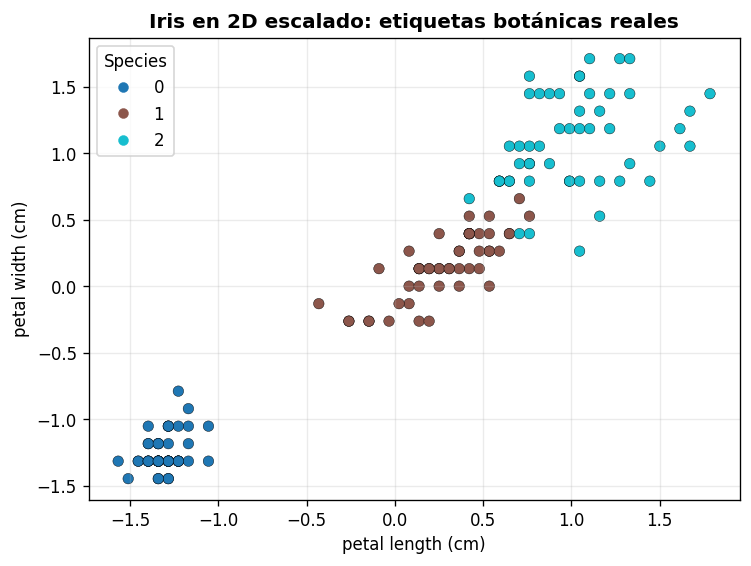

In [3]:

fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(
    X_full[:, 0],
    X_full[:, 1],
    c=y_full,
    cmap="tab10",
    s=40,
    edgecolors="k",
    linewidths=0.25,
)
ax.set_title("Iris en 2D escalado: etiquetas botánicas reales", fontweight="bold")
ax.set_xlabel(feature_cols[0])
ax.set_ylabel(feature_cols[1])
ax.legend(*scatter.legend_elements(), title="Species", loc="best")
plt.show()



## 3. Implementación 

La clase siguiente implementa el flujo de Wright con estas decisiones explícitas:

- masas iniciales unitarias;
- dinámica Markoviana de atracción unitaria;
- control del paso temporal para que la partícula más rápida recorra exactamente $\delta$ en cada iteración;
- colisiones sucesivas dentro del mismo instante cuando varias partículas quedan por debajo de $\epsilon$;
- registro de la jerarquía completa, de los tiempos de fusión y de una matriz de enlace utilizable para un dendrograma temporal.

La implementación devuelve dos tipos de lectura:

1. la **partición más fuerte** según la mayor vida temporal observada;
2. la partición correspondiente a cualquier nivel $k$ presente en la jerarquía.


In [15]:
class Wright1977GravitationalClustering:
    """
    Implementación del modelo gravitacional de Wright (1977) en su versión
    Markoviana, usando por defecto el modelo de atracción unitaria.

    Idea general del paper
    ----------------------
    Cada observación se interpreta como una partícula ubicada en un espacio
    euclidiano. Las partículas se atraen entre sí y se desplazan de manera
    iterativa. Cuando dos partículas quedan suficientemente cerca, colisionan
    y se reemplazan por una nueva partícula compuesta.

    En esta formulación:
    - cada partícula activa representa un clúster;
    - una colisión representa una fusión jerárquica;
    - el tiempo durante el cual el sistema permanece con k partículas
      se interpreta como la fuerza del nivel k de clustering.

    Parámetros
    ----------
    delta : float
        Máximo desplazamiento permitido para la partícula más rápida
        en una iteración. dt se elige para que el mayor
        desplazamiento en el paso sea aproximadamente delta.

    epsilon : float or None
        Umbral de colisión. Si es None, se usa epsilon = 2 * delta,
        siguiendo la recomendación práctica mencionada por Wright.

    max_iter : int
        Máximo número de iteraciones de simulación.

    mode : {"unit", "modified_physical"}
        - "unit": modelo Markoviano de atracción unitaria.
          La atracción entre dos partículas no depende de sus masas,
          pero el desplazamiento de la partícula i sí queda amortiguado
          por 1 / m_i.
        - "modified_physical": versión Markoviana modificada donde la
          atracción conserva la masa de la partícula atractora m_j y
          también incluye la amortiguación 1 / m_i.

    G : float
        Factor de escala de la dinámica. En la formulación del notebook
        se usa junto con el cálculo de dt para no alterar el máximo
        desplazamiento efectivo fijado por delta.
    """

    def __init__(self, delta=0.03, epsilon=None, max_iter=10000, mode="unit", G=1.0):
        # Parámetros de aproximación de la simulación.
        self.delta = float(delta)

        # Si el usuario no fija epsilon, se adopta epsilon = 2 * delta,
        # que es la elección práctica sugerida en el paper.
        self.epsilon = float(2 * delta if epsilon is None else epsilon)

        # Cota de seguridad para evitar bucles excesivamente largos.
        self.max_iter = int(max_iter)

        # Selección del modelo gravitacional específico.
        self.mode = mode

        # Constante de escala.
        self.G = float(G)

    def _displacement_base(self, pos, masses):
        """
        Calcula el campo de desplazamiento base para todas las partículas activas.

        Este método implementa la suma de contribuciones gravitacionales
        entre pares de partículas, tal como en la formulación Markoviana
        del paper. El desplazamiento final del paso será:

            move = G * dt^2 * base

        donde `base` contiene, para cada partícula i, la suma de términos
        del tipo:

            (coeficiente) * (vector dirección normalizado)

        con dependencia espacial inversa a ||s_j - s_i||^2 en el coeficiente,
        lo que equivale a una dependencia total inversa cúbica cuando se
        multiplica por el vector dirección.

        Parámetros
        ----------
        pos : array de shape (n_activos, d)
            Posiciones actuales de las partículas activas.
        masses : array de shape (n_activos,)
            Masas actuales de las partículas activas.

        Retorna
        -------
        base : array de shape (n_activos, d)
            Suma vectorial de atracciones para cada partícula activa,
            antes de multiplicar por G * dt^2.
        """
        n = len(pos)

        # diff[i, j] = s_j - s_i
        # Esto construye todos los vectores entre pares de partículas activas.
        diff = pos[np.newaxis, :, :] - pos[:, np.newaxis, :]

        # Distancia euclidiana al cuadrado entre todos los pares.
        dist_sq = np.sum(diff ** 2, axis=2)

        # Máscara para excluir la diagonal i = j.
        mask = ~np.eye(n, dtype=bool)

        # Evita divisiones por cero o inestabilidades numéricas.
        dist_sq_safe = np.where(mask, np.maximum(dist_sq, 1e-15), 1.0)
        dist = np.sqrt(dist_sq_safe)

        # Dirección unitaria desde i hacia j:
        # (s_j - s_i) / ||s_j - s_i||
        direction = np.where(mask[:, :, np.newaxis], diff / dist[:, :, np.newaxis], 0.0)

        # mi: masa de la partícula que se mueve.
        # mj: masa de la partícula atractora.
        mi = masses[:, np.newaxis]
        mj = masses[np.newaxis, :]

        if self.mode == "unit":
            # Modelo de atracción unitaria de Wright:
            # la intensidad de atracción entre i y j es 1,
            # pero el desplazamiento de i está amortiguado por 1 / m_i.
            #
            # Vectorialmente, esto implementa:
            #   (1 / m_i) * (s_j - s_i) / ||s_j - s_i||^3
            coeff = np.where(mask, 1.0 / (mi * dist_sq_safe), 0.0)

        elif self.mode == "modified_physical":
            # Variante Markoviana modificada "física":
            # conserva la masa de la partícula atractora m_j
            # y además divide por m_i.
            #
            # Vectorialmente:
            #   (m_j / m_i) * (s_j - s_i) / ||s_j - s_i||^3
            coeff = np.where(mask, mj / (mi * dist_sq_safe), 0.0)

        else:
            raise ValueError("mode debe ser 'unit' o 'modified_physical'")

        # Suma de contribuciones de todas las partículas j != i.
        return (coeff[:, :, np.newaxis] * direction).sum(axis=1)

    @staticmethod
    def _partition_to_labels(partition, n):
        """
        Convierte una partición representada como lista de clústeres
        en un vector de etiquetas de longitud n.

        Ejemplo:
            partition = [[0, 4], [1, 2, 3]]
            -> labels[0] = 0, labels[4] = 0, labels[1] = labels[2] = labels[3] = 1
        """
        labels = np.full(n, -1, dtype=int)
        for cid, cluster in enumerate(partition):
            labels[cluster] = cid
        return labels

    @staticmethod
    def _copy_partition(active, membership):
        """
        Construye una copia limpia de la partición actual usando únicamente
        las partículas activas.

        `membership[i]` contiene los índices originales que representa
        la partícula i. Esto permite rastrear la jerarquía de fusiones.
        """
        return [sorted(membership[i]) for i in np.where(active)[0] if membership[i]]

    def fit(self, X, masses=None):
        """
        Ejecuta la simulación gravitacional sobre el conjunto de datos X.

        Flujo general
        -------------
        1. Cada observación inicia como una partícula independiente.
        2. En cada iteración se calcula la atracción neta.
        3. Se escoge dt para que la partícula más rápida se mueva delta.
        4. Se actualizan posiciones.
        5. Si dos partículas quedan a distancia < epsilon, se fusionan.
        6. Se registra el tiempo y la partición resultante.
        7. Al final se construye la vida temporal de cada nivel k.

        Parámetros
        ----------
        X : array de shape (n, d)
            Datos en espacio euclidiano.
        masses : array de shape (n,), opcional
            Masas iniciales. Si no se especifican, todas comienzan con masa 1.

        Retorna
        -------
        self
        """
        X = np.asarray(X, dtype=float)
        n, _ = X.shape

        # Posiciones actuales de las partículas.
        pos = X.copy()

        # Si no se suministran masas, todas las partículas comienzan con masa 1.
        masses = np.ones(n, dtype=float) if masses is None else np.asarray(masses, dtype=float).copy()

        # Máscara booleana de partículas activas.
        active = np.ones(n, dtype=bool)

        # Cada partícula inicia representando un singleton {i}.
        membership = [[i] for i in range(n)]

        # Estructuras auxiliares para construir una matriz de linkage
        # compatible con dendrogramas.
        node_ids = np.arange(n, dtype=int)
        node_sizes = np.ones(2 * n - 1, dtype=int)
        next_node = n

        # Tiempo simulado total.
        t = 0.0

        # Registro de eventos de fusión.
        merge_log = []

        # Matriz linkage acumulada: [left, right, height, cluster_size]
        linkage = []

        # Historial de posiciones y tiempos para análisis posterior.
        history_positions = [pos.copy()]
        history_times = [0.0]
        history_n = [n]
        history_mean_move = []

        for _ in range(self.max_iter):
            active_idx = np.where(active)[0]

            # Si queda una sola partícula activa, termina la jerarquía.
            if len(active_idx) <= 1:
                break

            # Extrae solo las partículas activas.
            pos_act = pos[active_idx]
            mass_act = masses[active_idx]

            # Campo de atracción neto del modelo gravitacional elegido.
            base = self._displacement_base(pos_act, mass_act)

            # Norma máxima del campo de desplazamiento base.
            max_norm = np.linalg.norm(base, axis=1).max()

            # Si el sistema ya no presenta movimiento relevante, se detiene.
            if not np.isfinite(max_norm) or max_norm <= 1e-14:
                break

            # Elección de dt para que el mayor desplazamiento en este paso
            # sea aproximadamente delta:
            #
            #   max ||move_i|| = G * dt^2 * max_norm = delta
            #
            # de donde:
            #   dt = sqrt(delta / (G * max_norm))
            dt = math.sqrt(self.delta / (self.G * max_norm))

            # Desplazamiento de todas las partículas activas.
            move = self.G * (dt ** 2) * base

            # Actualización de posiciones.
            pos[active_idx] = pos_act + move

            # Avance del tiempo simulado.
            t += dt

            # Magnitud media del desplazamiento en este paso.
            history_mean_move.append(float(np.linalg.norm(move, axis=1).mean()))

            # Tras mover las partículas, se aplican todas las fusiones
            # necesarias mientras existan pares a distancia menor que epsilon.
            #
            # Esto implementa la idea del paper de tratar las colisiones
            # múltiples como secuencias de colisiones en el mismo instante.
            while True:
                active_idx = np.where(active)[0]
                if len(active_idx) <= 1:
                    break

                pos_act = pos[active_idx]

                # Matriz de distancias entre partículas activas.
                dists = np.linalg.norm(
                    pos_act[:, np.newaxis, :] - pos_act[np.newaxis, :, :],
                    axis=2
                )

                # La diagonal no debe participar.
                np.fill_diagonal(dists, np.inf)

                min_dist = dists.min()

                # Si ya no hay pares lo bastante cercanos, termina el bloque
                # de colisiones en este instante.
                if min_dist >= self.epsilon:
                    break

                # Se fusiona el par más cercano.
                i_local, j_local = np.unravel_index(np.argmin(dists), dists.shape)
                if i_local > j_local:
                    i_local, j_local = j_local, i_local

                i_global = active_idx[i_local]
                j_global = active_idx[j_local]

                # Masas de las dos partículas que colisionan.
                mi, mj = masses[i_global], masses[j_global]
                m_tot = mi + mj

                # La nueva partícula se ubica en el centroide ponderado por masa,
                # exactamente como en el modelo formal del paper.
                pos[i_global] = (mi * pos[i_global] + mj * pos[j_global]) / m_tot

                # La masa de la nueva partícula es la suma de masas.
                masses[i_global] = m_tot
                masses[j_global] = 0.0

                # Información para el dendrograma/linkage.
                left_id = node_ids[i_global]
                right_id = node_ids[j_global]
                new_id = next_node
                next_node += 1

                new_size = node_sizes[left_id] + node_sizes[right_id]
                node_sizes[new_id] = new_size

                # En esta implementación la "altura" del dendrograma es el tiempo
                # de fusión, lo cual es coherente con la interpretación temporal
                # del paper.
                linkage.append([left_id, right_id, float(t), int(new_size)])

                node_ids[i_global] = new_id
                node_ids[j_global] = -1

                # Actualiza la membresía del clúster resultante.
                membership[i_global].extend(membership[j_global])
                membership[j_global] = []

                # La partícula j deja de estar activa.
                active[j_global] = False

                # Registro del evento de fusión.
                merge_log.append(
                    {
                        "time": float(t),
                        "n_clusters_after": int(active.sum()),
                        "partition_after": self._copy_partition(active, membership),
                    }
                )

            # Guarda el estado tras completar todas las colisiones del instante.
            history_positions.append(pos.copy())
            history_times.append(float(t))
            history_n.append(int(active.sum()))

            if active.sum() <= 1:
                break

        # ------------------------------------------------------------------
        # Construcción de la vida temporal de cada nivel k
        # ------------------------------------------------------------------
        #
        # Si entre dos eventos consecutivos el sistema permaneció con k clústeres,
        # entonces ese intervalo temporal constituye la "vida" de ese nivel.
        #
        # Esta idea es central en Wright: un nivel k es fuerte si persiste
        # durante una fracción importante del tiempo total del sistema.
        level_intervals = []
        prev_time = 0.0
        prev_k = n
        prev_partition = [[i] for i in range(n)]

        for event in merge_log:
            level_intervals.append(
                {
                    "k": prev_k,
                    "start": prev_time,
                    "end": event["time"],
                    "lifetime": event["time"] - prev_time,
                    "partition": prev_partition,
                }
            )
            prev_time = event["time"]
            prev_k = event["n_clusters_after"]
            prev_partition = [cluster.copy() for cluster in event["partition_after"]]

        # Si la simulación termina sin una nueva fusión final, se cierra
        # el último intervalo observado.
        if prev_k > 1 and t > prev_time:
            level_intervals.append(
                {
                    "k": prev_k,
                    "start": prev_time,
                    "end": t,
                    "lifetime": t - prev_time,
                    "partition": prev_partition,
                }
            )

        # ------------------------------------------------------------------
        # Atributos finales del ajuste
        # ------------------------------------------------------------------
        self.history_ = {
            "positions": history_positions,
            "times": history_times,
            "n_particles": history_n,
            "mean_move": history_mean_move,
        }

        self.merge_log_ = pd.DataFrame(merge_log)
        self.level_intervals_ = pd.DataFrame(level_intervals)
        self.total_time_ = float(t)
        self.final_positions_ = pos.copy()

        # Matriz linkage para construir dendrograma temporal.
        self.linkage_matrix_ = (
            np.asarray(linkage, dtype=float)
            if linkage else np.empty((0, 4), dtype=float)
        )

        # Selección del nivel "más fuerte":
        # el nivel k > 1 con mayor vida temporal.
        strongest = (
            self.level_intervals_[self.level_intervals_["k"] > 1]
            .sort_values(["lifetime", "k"], ascending=[False, True])
            .iloc[0]
        )

        self.strongest_k_ = int(strongest["k"])
        self.strongest_partition_ = strongest["partition"]
        self.strongest_lifetime_ = float(strongest["lifetime"])
        self.strongest_labels_ = self._partition_to_labels(self.strongest_partition_, n)

        # Por conveniencia, labels_ y n_clusters_ se fijan como la
        # partición más fuerte según el criterio temporal de Wright.
        self.labels_ = self.strongest_labels_.copy()
        self.n_clusters_ = self.strongest_k_

        return self

    def labels_at_k(self, k):
        """
        Devuelve las etiquetas correspondientes al nivel k más estable
        observado en la simulación.

        Si un mismo valor de k aparece en varios intervalos, se elige el de
        mayor vida temporal, porque en el marco de Wright ese es el más fuerte.
        """
        if len(self.level_intervals_) == 0:
            raise ValueError("No se registraron fusiones.")

        sub = self.level_intervals_[self.level_intervals_["k"] == k]
        if len(sub) == 0:
            raise ValueError(f"No se observó un nivel k={k} en la simulación.")

        best_row = sub.sort_values("lifetime", ascending=False).iloc[0]
        labels = self._partition_to_labels(best_row["partition"], len(self.labels_))
        return labels, float(best_row["lifetime"])

In [ ]:
def partition_inertia(X, labels):
    """
    Calcula la inercia interna de una partición dada.

    Interpretación
    --------------
    Aunque la inercia no es una métrica propuesta por Wright (1977),
    aquí se usa como medida complementaria moderna para cuantificar
    la compactación interna de los clústeres producidos por el modelo.

    La inercia se define como la suma, sobre todos los clústeres, de las
    distancias cuadradas de cada punto al centroide de su propio clúster:

        Inercia = \\sum_{c=1}^k \\sum_{x_i \\in C_c} ||x_i - \\mu_c||^2

    donde:
    - C_c es el clúster c,
    - \\mu_c es el centroide del clúster c.

    Cuanto menor sea la inercia:
    - más compactos son los grupos,
    - menor dispersión interna presentan.

    Parámetros
    ----------
    X : array-like de shape (n_samples, n_features)
        Matriz de datos.
    labels : array-like de shape (n_samples,)
        Etiquetas de clúster asignadas a cada observación.

    Retorna
    -------
    total : float
        Inercia total de la partición.
    """
    X = np.asarray(X)
    total = 0.0

    # Recorre cada etiqueta de clúster presente en la partición.
    for lab in np.unique(labels):
        # Extrae los puntos pertenecientes al clúster actual.
        pts = X[labels == lab]

        # Calcula el centroide del clúster.
        centroid = pts.mean(axis=0)

        # Acumula la suma de cuadrados dentro del clúster.
        total += ((pts - centroid) ** 2).sum()

    return total


def summarize_model(model, X, y_true=None, max_k=10):
    """
    Resume cuantitativamente los niveles jerárquicos observados
    en la simulación gravitacional de Wright.

    Contexto
    --------
    En el paper de Wright, la lectura principal de la jerarquía se hace
    mediante la vida temporal de cada nivel k: un nivel se considera más
    fuerte si el sistema permanece más tiempo con exactamente k partículas
    (o clústeres) activas.

    Esta función conserva esa idea y la complementa con métricas modernas:
    - lifetime: vida temporal absoluta del nivel k,
    - life_pct: proporción de la vida total del sistema ocupada por ese nivel,
    - silhouette: separación/cohesión de la partición en el espacio de datos,
    - inertia: compactación interna de la partición,
    - ARI: concordancia con etiquetas reales, si están disponibles.

    Parámetros
    ----------
    model : Wright1977GravitationalClustering
        Modelo ya ajustado con fit().
    X : array-like de shape (n_samples, n_features)
        Datos originales sobre los que se evalúan las particiones.
    y_true : array-like de shape (n_samples,), opcional
        Etiquetas reales. Si se proporcionan, se calcula ARI.
    max_k : int, default=10
        Máximo valor de k a resumir.

    Retorna
    -------
    DataFrame
        Tabla resumen con una fila por cada nivel k observado.
    """
    rows = []

    # Obtiene todos los valores de k que aparecieron en la simulación,
    # es decir, los niveles jerárquicos que realmente existieron.
    observed_ks = sorted(model.level_intervals_["k"].unique())

    # Se filtran niveles no triviales:
    # - se excluye k = 1, porque corresponde al colapso total en un solo clúster;
    # - se limita a max_k para facilitar el análisis.
    observed_ks = [int(k) for k in observed_ks if 1 < k <= max_k]

    for k in observed_ks:
        # Recupera la partición "más estable" observada para este valor de k,
        # es decir, la que tuvo mayor vida temporal entre todas las veces
        # que el sistema pasó por ese nivel.
        labels, lifetime = model.labels_at_k(k)

        # Construye una fila con métricas descriptivas del nivel k.
        row = {
            "k": k,

            # Vida absoluta del nivel k en tiempo simulado.
            "lifetime": lifetime,

            # Proporción de la vida total del sistema que estuvo en este nivel.
            # Esta es la métrica más alineada con la interpretación original
            # de Wright sobre fuerza del clustering.
            "life_pct": lifetime / model.total_time_,

            # Métrica moderna de cohesión/separación.
            # Más alto suele indicar una partición geométricamente más clara.
            "silhouette": silhouette_score(X, labels),

            # Métrica moderna de compactación interna.
            # Más bajo suele indicar clústeres más compactos.
            "inertia": partition_inertia(X, labels),
        }

        # Si se conocen las clases reales, se agrega ARI para medir
        # concordancia entre la partición encontrada y la referencia externa.
        if y_true is not None:
            row["ARI"] = adjusted_rand_score(y_true, labels)

        rows.append(row)

    # Devuelve una tabla ordenada por número de clústeres.
    return pd.DataFrame(rows).sort_values("k").reset_index(drop=True)


## 4. Sensibilidad numérica respecto a $\delta$

$\delta$ es un parámetro de aproximación numérica y no un parámetro sustantivo del modelo. Por ello, antes de fijar una corrida principal conviene comprobar que la lectura jerárquica sea estable para varios valores pequeños de $\delta$.

La tabla siguiente resume esa sensibilidad para el conjunto completo de *Iris*.


In [6]:

delta_grid = [0.02, 0.03, 0.05, 0.08, 0.10]
sensitivity_rows = []

for delta in delta_grid:
    model = Wright1977GravitationalClustering(delta=delta, epsilon=2 * delta, max_iter=10000, mode="unit")
    model.fit(X_full)

    labels_strong = model.strongest_labels_
    labels_k3, life_k3 = model.labels_at_k(3)

    sensitivity_rows.append(
        {
            "delta": delta,
            "strongest_k": model.strongest_k_,
            "life_pct_strong": model.strongest_lifetime_ / model.total_time_,
            "silhouette_strong": silhouette_score(X_full, labels_strong),
            "ARI_strong": adjusted_rand_score(y_full, labels_strong),
            "life_pct_k3": life_k3 / model.total_time_,
            "silhouette_k3": silhouette_score(X_full, labels_k3),
            "ARI_k3": adjusted_rand_score(y_full, labels_k3),
        }
    )

sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_df


,delta,strongest_k,life_pct_strong,silhouette_strong,ARI_strong,life_pct_k3,silhouette_k3,ARI_k3
0,0.02,2,0.853102,0.743372,0.568116,0.097167,0.674131,0.885697
1,0.03,2,0.860852,0.743372,0.568116,0.088779,0.674131,0.885697
2,0.05,2,0.854915,0.743372,0.568116,0.094272,0.671974,0.903714
3,0.08,2,0.875307,0.743372,0.568116,0.070022,0.670302,0.922177
4,0.10,2,0.889541,0.743372,0.568116,0.054513,0.672912,0.903768



La estabilidad observada permite fijar una corrida principal con $\delta = 0.03$ y $\epsilon = 2\delta = 0.06$. Es un valor pequeño, coherente con la idea de aproximar la dinámica continua sin imponer un costo computacional excesivo.


In [7]:

model_full = Wright1977GravitationalClustering(delta=0.03, epsilon=0.06, max_iter=10000, mode="unit")
model_full.fit(X_full)

full_summary = summarize_model(model_full, X_full, y_true=y_full, max_k=10)
full_summary


,k,lifetime,life_pct,silhouette,inertia,ARI
0,2,95.440607,0.860852,0.743372,54.168781,0.568116
1,3,9.842725,0.088779,0.674131,18.026963,0.885697
2,4,1.505176,0.013576,0.595702,13.446808,0.780683
3,5,1.672203,0.015083,0.565906,9.390149,0.673108
4,6,0.514213,0.004638,0.574709,7.790346,0.648261
5,7,0.416826,0.003760,0.568909,6.401673,0.599989
6,8,0.253183,0.002284,0.588153,5.187895,0.576085
7,9,0.213954,0.001930,0.575197,4.934311,0.569783
8,10,0.036361,0.000328,0.469578,4.201668,0.461133



## 5. Lectura del conjunto completo de *Iris*

Wright reporta que, al considerar las tres especies juntas, la separación dominante aparece en **dos grupos**: por un lado *Iris setosa* y por otro el bloque formado por *versicolor* y *virginica*. Esa es precisamente la lectura que debe recuperarse si la implementación es fiel al paper.

En este notebook se presentan dos cortes relevantes:

1. **nivel más fuerte** según el criterio temporal de Wright;
2. **nivel $k=3$**, usado solo como contraste con la taxonomía botánica de tres especies.


In [8]:

labels_full_strong = model_full.strongest_labels_
labels_full_k3, life_full_k3 = model_full.labels_at_k(3)

results_full = pd.DataFrame(
    [
        {
            "reading": "Nivel más fuerte (criterio temporal de Wright)",
            "k": model_full.strongest_k_,
            "life_pct": model_full.strongest_lifetime_ / model_full.total_time_,
            "silhouette": silhouette_score(X_full, labels_full_strong),
            "ARI_vs_species": adjusted_rand_score(y_full, labels_full_strong),
        },
        {
            "reading": "Corte en k = 3 (contraste con especies)",
            "k": 3,
            "life_pct": life_full_k3 / model_full.total_time_,
            "silhouette": silhouette_score(X_full, labels_full_k3),
            "ARI_vs_species": adjusted_rand_score(y_full, labels_full_k3),
        },
    ]
)
results_full


,reading,k,life_pct,silhouette,ARI_vs_species
0,Nivel más fuerte (criterio temporal de Wright),2,0.860852,0.743372,0.568116
1,Corte en k = 3 (contraste con especies),3,0.088779,0.674131,0.885697


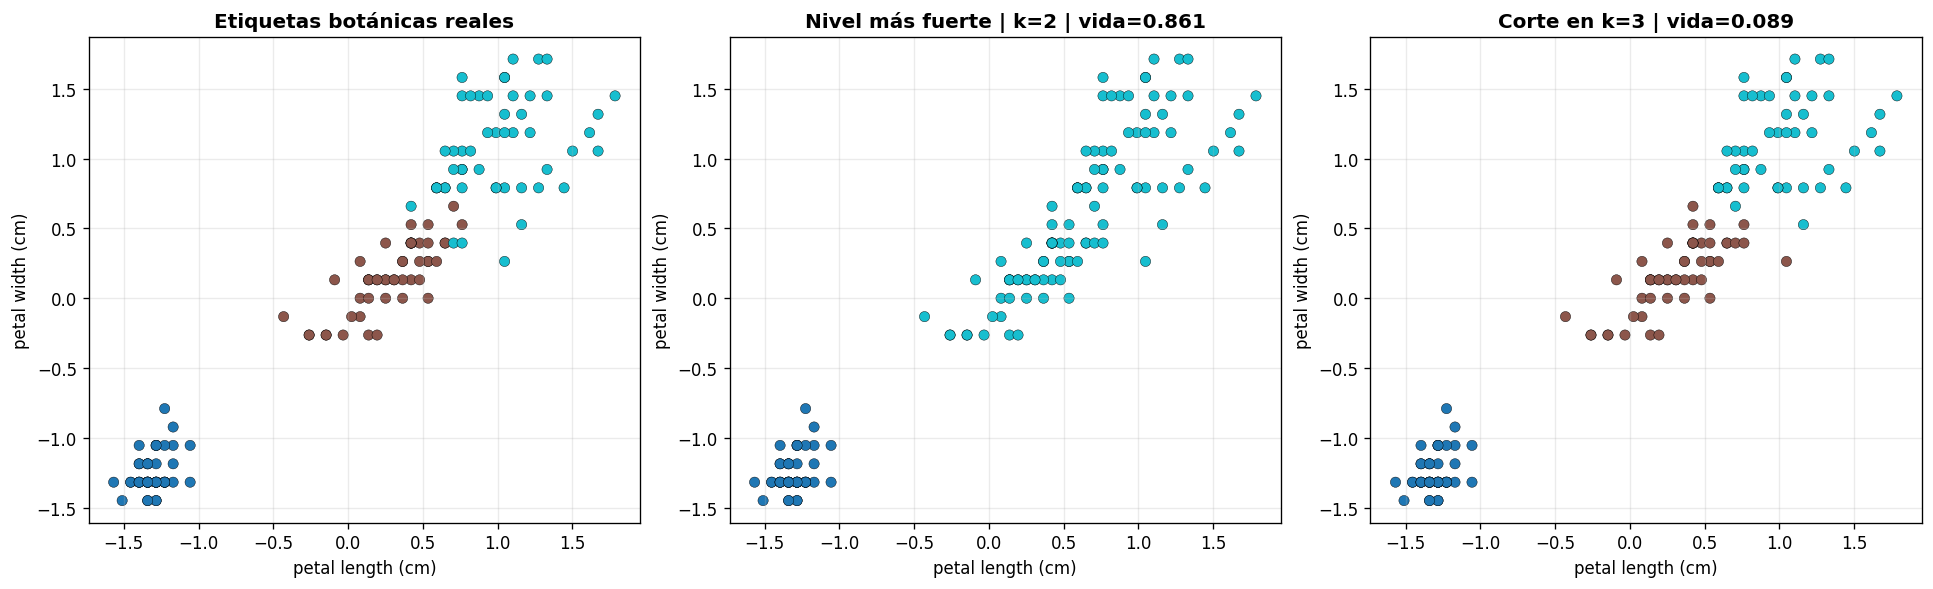

In [9]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)

sc0 = axes[0].scatter(
    X_full[:, 0], X_full[:, 1], c=y_full, cmap="tab10", s=38,
    edgecolors="k", linewidths=0.25
)
axes[0].set_title("Etiquetas botánicas reales", fontweight="bold")
axes[0].set_xlabel(feature_cols[0])
axes[0].set_ylabel(feature_cols[1])

axes[1].scatter(
    X_full[:, 0], X_full[:, 1], c=labels_full_strong, cmap="tab10", s=38,
    edgecolors="k", linewidths=0.25
)
axes[1].set_title(
    f"Nivel más fuerte | k={model_full.strongest_k_} | "
    f"vida={model_full.strongest_lifetime_ / model_full.total_time_:.3f}",
    fontweight="bold",
)
axes[1].set_xlabel(feature_cols[0])
axes[1].set_ylabel(feature_cols[1])

axes[2].scatter(
    X_full[:, 0], X_full[:, 1], c=labels_full_k3, cmap="tab10", s=38,
    edgecolors="k", linewidths=0.25
)
axes[2].set_title(
    f"Corte en k=3 | vida={life_full_k3 / model_full.total_time_:.3f}",
    fontweight="bold",
)
axes[2].set_xlabel(feature_cols[0])
axes[2].set_ylabel(feature_cols[1])

plt.show()


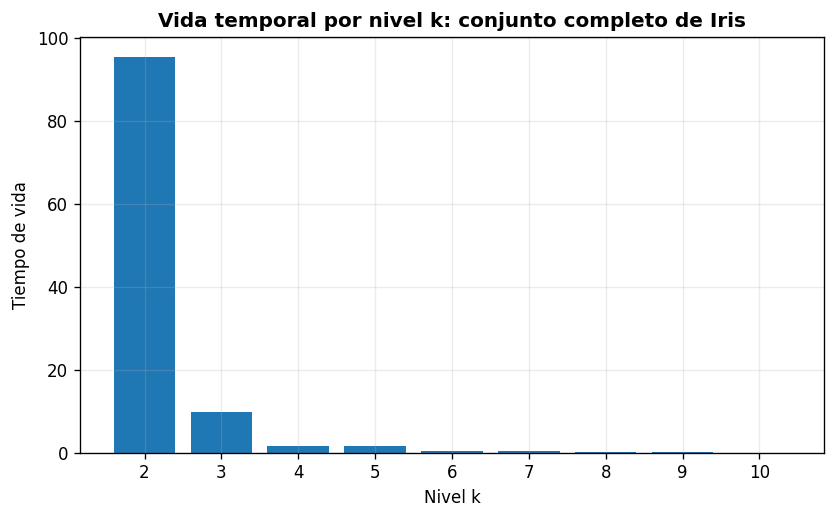

In [10]:

level_plot = full_summary.copy()
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(level_plot["k"].astype(str), level_plot["lifetime"])
ax.set_title("Vida temporal por nivel k: conjunto completo de Iris", fontweight="bold")
ax.set_xlabel("Nivel k")
ax.set_ylabel("Tiempo de vida")
plt.show()



La tabla y las figuras anteriores permiten leer el resultado exactamente en el espíritu de Wright:

- el sistema pasa la mayor parte de su vida en **$k=2$**;
- el corte en **$k=3$** existe y es útil para comparar contra las tres especies, pero es mucho menos estable temporalmente;
- por tanto, la lectura principal del modelo en 2D es la fuerte separación de *setosa* respecto del resto.



## 7. Silhouette y Elbow

1. **Silhouette** para distintos niveles $k$ observados en la simulación.
2. **Curva tipo elbow** usando la inercia intraclúster de las particiones gravitacionales.
3. **Dendrograma temporal** construido a partir de los tiempos de fusión.


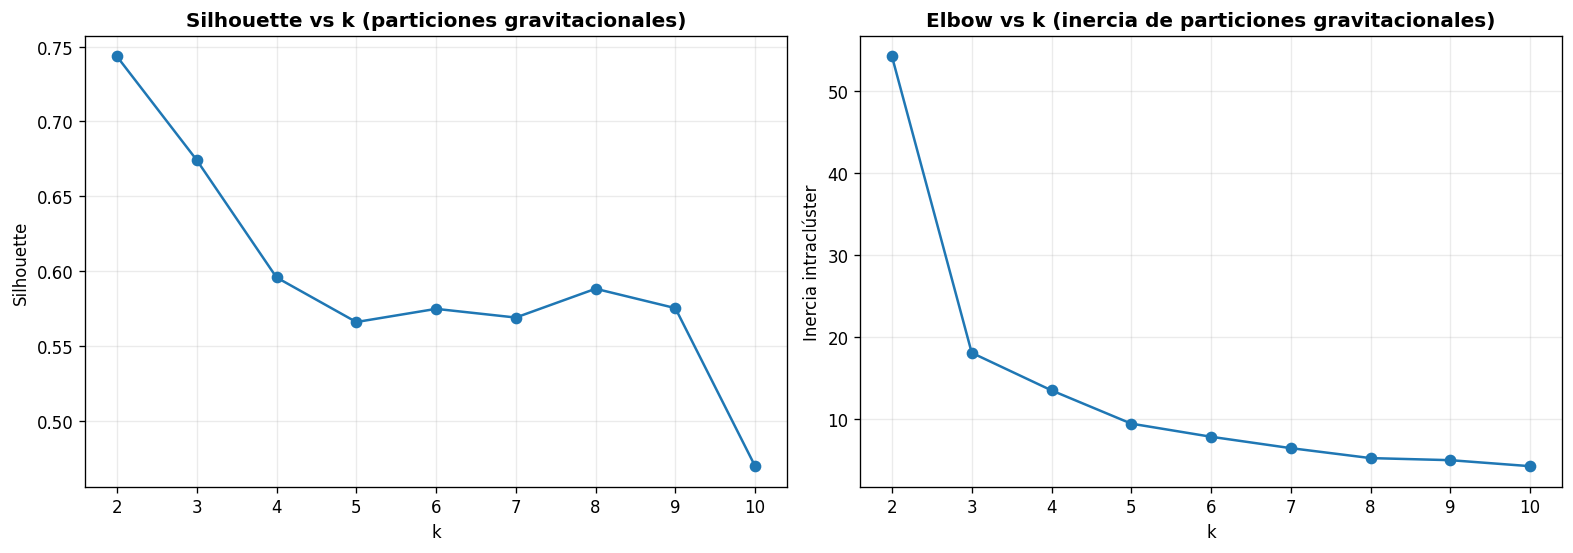

In [13]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)

axes[0].plot(full_summary["k"], full_summary["silhouette"], marker="o")
axes[0].set_title("Silhouette vs k (particiones gravitacionales)", fontweight="bold")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Silhouette")
axes[0].set_xticks(full_summary["k"])

axes[1].plot(full_summary["k"], full_summary["inertia"], marker="o")
axes[1].set_title("Elbow vs k (inercia de particiones gravitacionales)", fontweight="bold")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Inercia intraclúster")
axes[1].set_xticks(full_summary["k"])

plt.show()


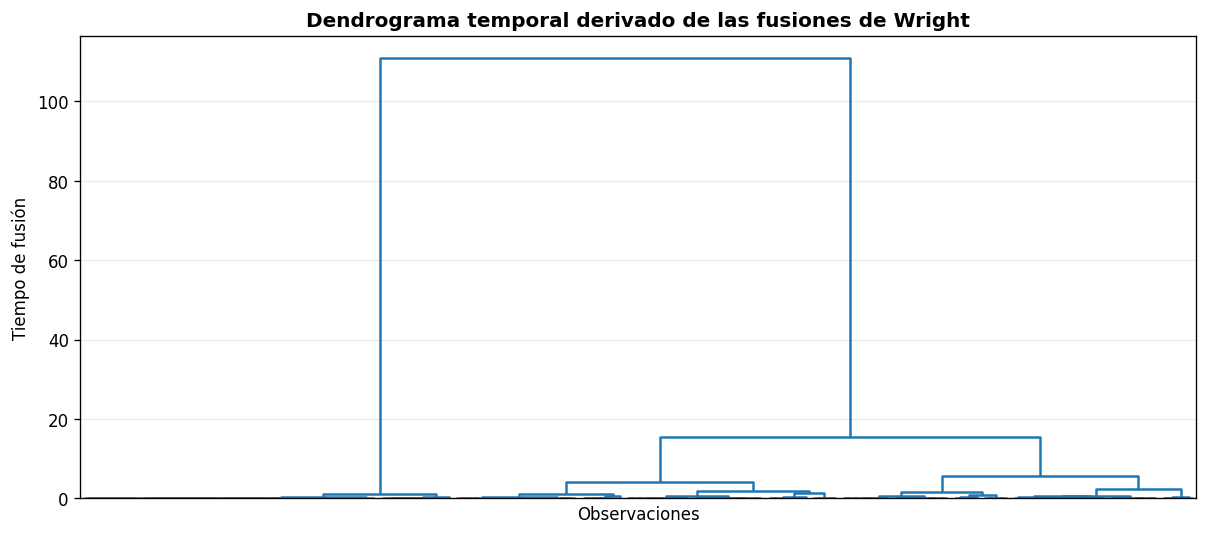

In [14]:

fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(model_full.linkage_matrix_, no_labels=True, color_threshold=0.0, ax=ax)
ax.set_title("Dendrograma temporal derivado de las fusiones de Wright", fontweight="bold")
ax.set_xlabel("Observaciones")
ax.set_ylabel("Tiempo de fusión")
plt.show()



## 8. Discusión final

### 8.1 Resultado principal

Para el conjunto completo de *Iris* en esta proyección bidimensional, la estructura dominante aparece en **dos grupos**. Esto coincide con la lectura clásica del paper: *setosa* se separa tempranamente y permanece como un bloque estable frente al conglomerado formado por *versicolor* y *virginica*.

### 8.2 Papel del corte en $k=3$

El corte en $k=3$ reproduce razonablemente bien la taxonomía botánica y, en esta corrida, presenta un acuerdo alto con las etiquetas reales. Sin embargo, desde el punto de vista de Wright, esa no es la lectura primaria, porque su vida temporal es mucho menor que la del nivel $k=2$.

### 8.4 Lectura de los diagnósticos complementarios

La curva de silhouette y la curva tipo elbow sirven como contraste. En este ejemplo, ambas favorecen particiones pequeñas y relativamente compactas, lo cual refuerza la conclusión de que la estructura de dos grupos es la más estable en la representación 2D usada aquí. El dendrograma temporal, por su parte, complementa la presentación porque traduce la secuencia de fusiones del algoritmo a un formato jerárquico familiar.
